# This script is to read in the .prof and measurement files for comparisons

In [122]:
import pandas as pd 
import glob
from pathlib import Path
import numpy as np

import astropy.units as u
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization import simple_norm
from astropy.stats import sigma_clip

import matplotlib.pyplot as plt

import sys
import os

from astropy.cosmology import Planck18 as cosmo
from astropy.cosmology import FlatLambdaCDM
h=0.7
cosmo=FlatLambdaCDM(H0=h*100, Om0=0.3)

In [129]:
def load_profiles_and_measurements(
    outdir,
    cluster_id,
    filter_name,
    prefixes,
    arcsec_to_kpc=None,
    pixelscale=0.3,
    load_measurements=True,
    external_measurement_paths=None
):
    
    profiles = []
    measurements = []

    for prefix in prefixes:
        label = prefix if prefix else "fluctuations"

        prof_file = outdir / cluster_id / "autoprof_results" / f"{cluster_id}_{filter_name}{'_' + prefix if prefix else ''}.prof"
        if prof_file.exists():
            prof = pd.read_csv(prof_file, skiprows=1)
            profiles.append((label, prof))
        else:
            print(f"Profile file not found: {prof_file}")

        if load_measurements:
            meas_file = outdir / cluster_id / (f"Profile_measurements_{prefix}.csv" if prefix else "Profile_measurements.csv")
            if meas_file.exists():
                meas = pd.read_csv(meas_file)
                measurements.append((label, meas))
            else:
                print(f"Measurement file not found: {meas_file}")

    # Load external measurements if provided
    if external_measurement_paths:
        for label, path in external_measurement_paths.items():
            path = Path(path)
            if path.exists():
                ext_meas = pd.read_csv(path)
                measurements.append((label, ext_meas))
            else:
                print(f"External measurement file not found: {path}")

    return profiles, measurements


In [130]:
def plot_sb_profiles(
    profiles=None,
    measurements=None,
    prefix_colors=None,
    pixelscale=0.3,
    rad_output_unit='pix',
    cosmology=None,
    redshift=None,
    specific_profile_prefix=None,
    plot_profiles=True,
    plot_measurements=True,
    xlog=True,
    ylog=True,
    ax=None
):
    if prefix_colors is None:
        prefix_colors = {}

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    allowed_labels = set(specific_profile_prefix) if specific_profile_prefix else None

    # Unit scaling
    if rad_output_unit == 'pix':
        scale_conversion = pixelscale
    elif rad_output_unit == 'arcsec':
        scale_conversion = 1
    elif rad_output_unit == 'kpc':
        if cosmology is None or redshift is None:
            raise ValueError("To convert to kpc, cosmology and redshift must be provided.")
        scale_conversion = 1 / cosmology.arcsec_per_kpc_proper(redshift).value
    else:
        raise ValueError(f"Unsupported rad_output_unit: {rad_output_unit}")

    styles = {
        'isophote': {'linestyle': '-', 'marker': 'o'},
        'annuli': {'linestyle': '--', 'marker': 's'},
        'external': {'linestyle': ':', 'marker': '^'}
    }

    # Plot AutoProf profiles
    if plot_profiles and profiles:
        for label, prof in profiles:
            if allowed_labels and label not in allowed_labels:
                continue
            color = prefix_colors.get(label, "black")

            if 'R' in prof and 'I' in prof:
                ax.plot(
                    prof['R'] * scale_conversion,
                    prof['I'],
                    label=f"AP Isophote - {label}",
                    color=color,
                    linestyle=styles['isophote']['linestyle'],
                    marker=styles['isophote']['marker'],
                    ms=3,
                    alpha=0.7
                )

            if 'SMA_annulus_centre' in prof and 'Median_flux_annulus' in prof:
                ax.plot(
                    prof['SMA_annulus_centre'] * scale_conversion,
                    prof['Median_flux_annulus'],
                    label=f"AP Annuli - {label}",
                    color=color,
                    linestyle=styles['annuli']['linestyle'],
                    marker=styles['annuli']['marker'],
                    ms=3,
                    alpha=0.7
                )

    # Plot external annuli measurements
    if plot_measurements and measurements:
        for label, meas in measurements:
            if allowed_labels and label not in allowed_labels:
                continue
            color = prefix_colors.get(label, "black")

            # Assume radius is given in arcsec; apply scaling
            if 'Radial_Bin_Centre_arcsec' in meas:
                radius = meas["Radial_Bin_Centre_arcsec"] * scale_conversion
            else:
                raise KeyError("Expected 'Radial_Bin_Centre_arcsec' in measurement data.")

            ax.plot(
                radius,
                meas["Clipped_median_flux_annulus"],
                label=f"External Annuli - {label}",
                color=color,
                linestyle=styles['external']['linestyle'],
                marker=styles['external']['marker'],
                ms=3,
                alpha=0.7
            )

    # Final plot formatting
    ax.set_xlabel(f"R ({rad_output_unit})")
    ax.set_ylabel(r"Surface Brightness (flux / arcsec$^2$)")

    if xlog:
        ax.set_xscale('log')
    if ylog:
        ax.set_yscale('log')

    ax.legend()
    return ax


In [131]:
def plot_residual_comparison(
    reference_label,
    reference_from="measurements",   # "profiles" or "measurements"
    compare_from="measurements",     # "profiles" or "measurements"
    profiles=None,
    measurements=None,
    prefix_colors=None,
    ax=None,
    xlims = [None,None],
    ylims = [None,None]
):
    if prefix_colors is None:
        prefix_colors = {}

    if reference_from == "profiles":
        if profiles is None:
            raise ValueError("You must provide `profiles` when using 'profiles' as reference.")
        ref_data = {label: df for label, df in profiles}
        ref_col = "I"
    else:
        if measurements is None:
            raise ValueError("You must provide `measurements` when using 'measurements' as reference.")
        ref_data = {label: df for label, df in measurements}
        ref_col = "Clipped_median_flux_annulus"

    if reference_label not in ref_data:
        raise ValueError(f"Reference label '{reference_label}' not found in {reference_from}!")

    ref_df = ref_data[reference_label]
    ref_r = ref_df["R_kpc"].values
    ref_flux = ref_df[ref_col].values

    if compare_from == "profiles":
        if profiles is None:
            raise ValueError("You must provide `profiles` when using 'profiles' as comparison data.")
        compare_data = profiles
        compare_col = "I"
    else:
        if measurements is None:
            raise ValueError("You must provide `measurements` when using 'measurements' as comparison data.")
        compare_data = measurements
        compare_col = "Clipped_median_flux_annulus"

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    for label, df in compare_data:
        if label == reference_label and compare_from == reference_from:
            continue

        other_r = df["R_kpc"].values
        other_flux = df[compare_col].values

        ref_interp_flux = np.interp(other_r, ref_r, ref_flux)
        residual_fraction = (ref_interp_flux - other_flux) / ref_interp_flux

        color = prefix_colors.get(label, "black")
        ax.plot(
            other_r, residual_fraction,
            label=f"{label} vs {reference_label}",
            color=color,
            linestyle="-",
            marker="o",
            ms=3,
            alpha=0.7
        )

    ax.axhline(0, color="gray", linestyle="--", lw=1)
    ax.set_xscale('log')
    ax.set_xlabel("R [kpc]")
    ax.set_ylabel(
        fr"(SB$_{{{reference_label}}}$ - SB$_{{profile}}$) / SB$_{{{reference_label}}}$"
    )
    ax.set_title(f"Fractional Residuals in SB ({compare_from} vs {reference_from})")
    ax.legend()
    if xlims:
        ax.set_xlim(xlims[0], xlims[1])
    
    if ylims:
        ax.set_ylim(ylims[0], ylims[1])
    else:
        ax.set_ylim(-0.1, 0.1)
    plt.tight_layout()
    if savefig:
        label = f"SB_fractional_change_{compare_from}_vs_{reference_from}.pdf"
        plt.savefig(plotdir/label)
    plt.show()


In [134]:
outdir = Path('/home/ppztk1/Erosita/Outputs_Clusters/')
plotdir = outdir
cluster_id = 'cluster'
filter_name = 'H'

pixelscale = 0.3  # arcsec/pix
cluster_z = 0.3
arcsec_to_kpc = cosmo.arcsec_per_kpc_proper(cluster_z).value

prefixes = ["", "no_noise", "random_field_growth_0.25", "random_field_growth_0.5", "random_field_growth_1"]
prefixes = ["no_noise"]

prefix_colors = {
    "fluctuations": "tab:olive",   # corresponds to "" prefix
    "no_noise": "teal",
    "loaded_mask": "tab:green",
    "random_field": "hotpink",
    "random_field_growth_0.25":"red",
    "random_field_growth_0.5":"gold",
    "random_field_growth_1":"orange",
    "random_field_growth_1.25":"purple",

}

profiles = load_profiles_and_measurements(outdir, cluster_id, filter_name, prefixes, arcsec_to_kpc, pixelscale)

profiles

([('no_noise',
                 R          I           I_e      totflux  totflux_e     ellip  \
   0      0.420000  35.155146  2.565063e-02    14.943060   0.168164  0.328623   
   1      0.588000  26.505474  6.651844e-03    25.697549   0.182452  0.328623   
   2      0.823200  20.880428  2.383496e-03    40.905994   0.276683  0.411306   
   3      1.152480  15.647838  4.176735e-03    62.221531   0.362615  0.418510   
   4      1.613472  11.448757  3.151162e-04    93.551319   0.449652  0.396587   
   5      2.258861   8.256641  2.381511e-04   138.806487   0.470001  0.400891   
   6      3.162405   5.788606  9.199226e-05   201.695138   0.501921  0.400122   
   7      4.427367   3.956700  4.102404e-05   287.103221   0.564909  0.400013   
   8      6.198314   2.628099  4.782199e-04   399.953728   0.560722  0.400034   
   9      8.677640   1.686209  2.226903e-04   544.354245   0.655631  0.400939   
   10    12.148696   1.054924  9.535349e-05   723.492443   0.692271  0.402147   
   11    17.0

ValueError: not enough values to unpack (expected 2, got 1)

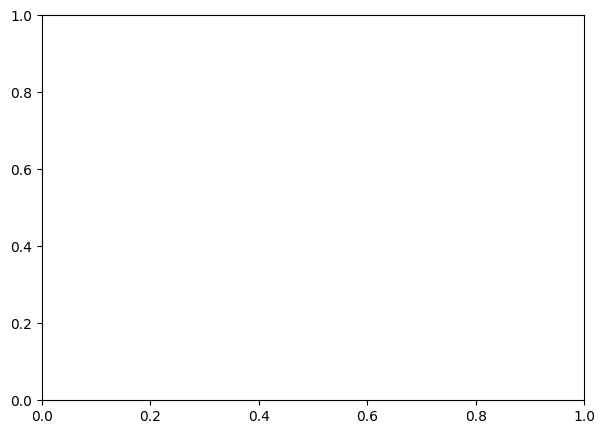

In [138]:
fix, ax = plt.subplots(1,1,figsize=(7,5))
plot_sb_profiles(profiles=profiles,prefix_colors=prefix_colors, specific_profile_prefix=['no_noise'], ax=ax)
# plot_sb_profiles(measurements=measurements,prefix_colors=prefix_colors, specific_profile_prefix=['no_noise'],ax=ax)

In [136]:
plot_sb_profiles?

Signature:
plot_sb_profiles(
    profiles=None,
    measurements=None,
    prefix_colors=None,
    pixelscale=0.3,
    rad_output_unit='pix',
    cosmology=None,
    redshift=None,
    specific_profile_prefix=None,
    plot_profiles=True,
    plot_measurements=True,
    xlog=True,
    ylog=True,
    ax=None,
)
Docstring: <no docstring>
File:      /tmp/ipykernel_786039/3215805681.py
Type:      function

<Axes: title={'center': 'Surface Brightness Profiles'}, xlabel='R [kpc]', ylabel='Surface Brightness (flux / arcsec²)'>

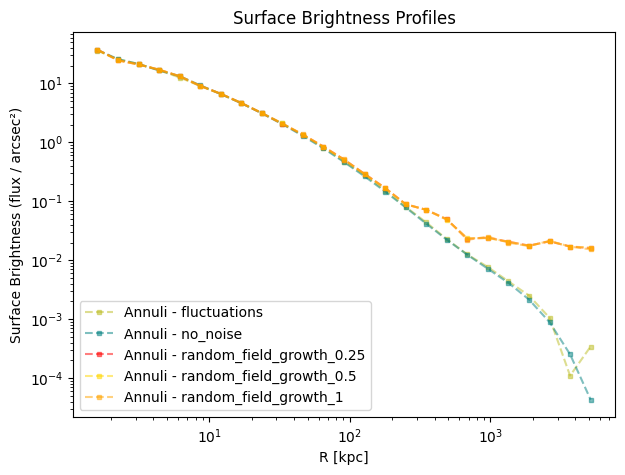

In [97]:
plot_sb_profiles(measurements=measurements,prefix_colors=prefix_colors)


<Axes: title={'center': 'Surface Brightness Profiles'}, xlabel='R [kpc]', ylabel='Surface Brightness (flux / arcsec²)'>

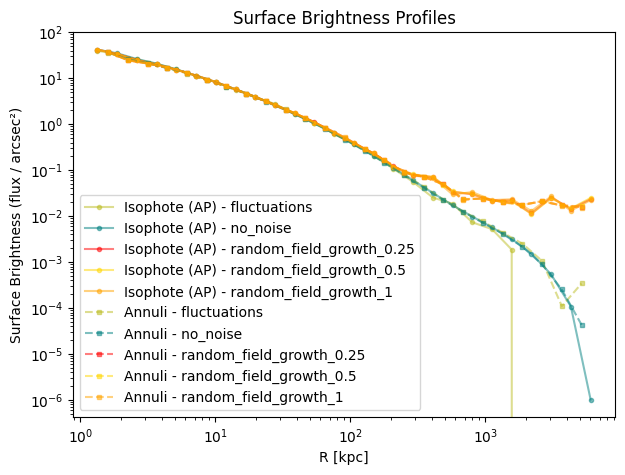

In [98]:
plot_sb_profiles(profiles=profiles, measurements=measurements,prefix_colors=prefix_colors)


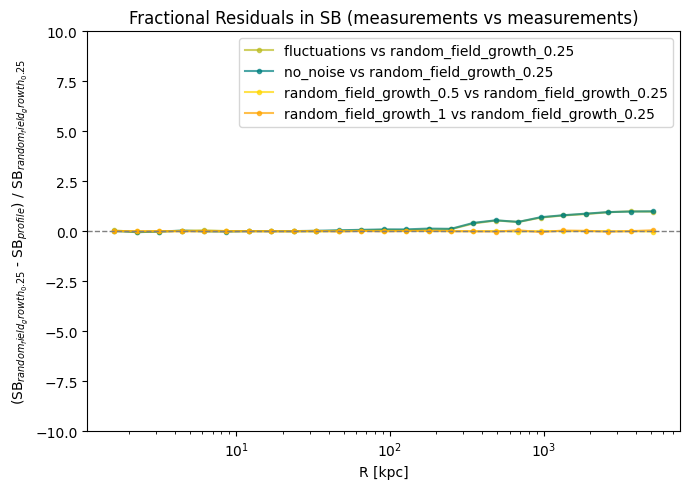

In [112]:
plot_residual_comparison(
    reference_label="random_field_growth_0.25",
    reference_from="measurements",
    compare_from="measurements",
    measurements=measurements,
    prefix_colors=prefix_colors,
    ylims=[-10,10],

)



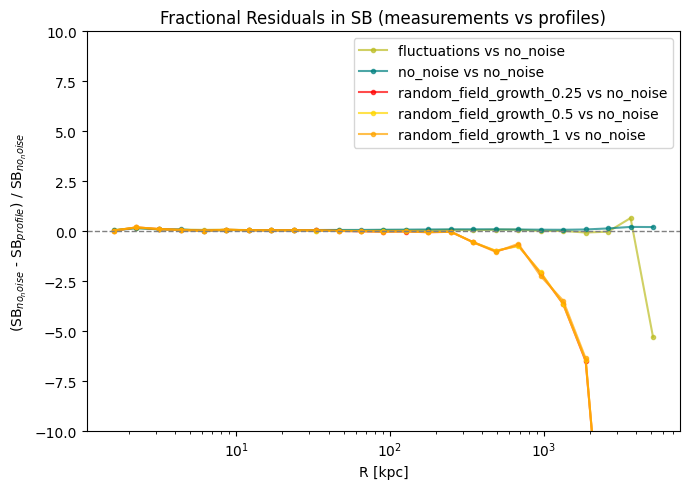

In [115]:
plot_residual_comparison(
    reference_label="no_noise",
    reference_from="profiles",
    compare_from="measurements",
    measurements=measurements,
    profiles=profiles,
    prefix_colors=prefix_colors,
    ylims=[-10,10],
    
)


# Plotting shape profiles


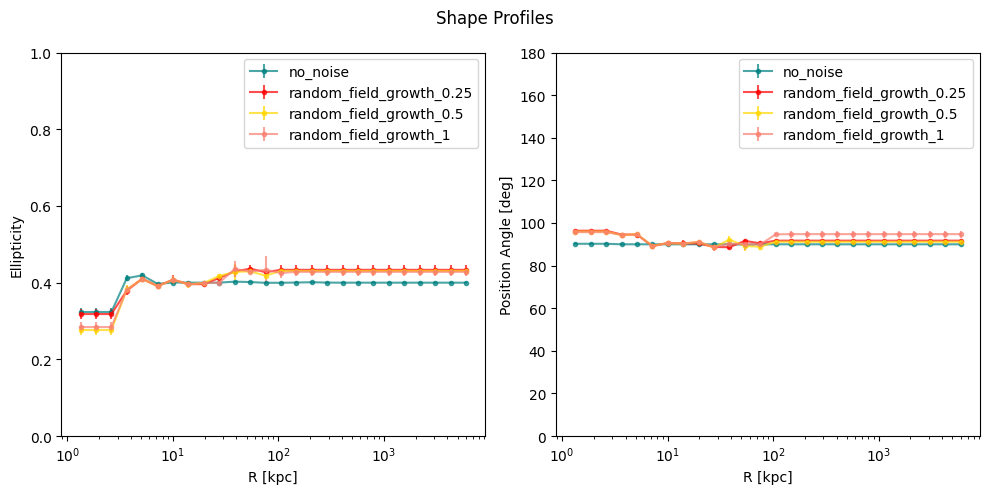

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True)

for label, prof in profiles:
    color = prefix_colors.get(label, "black")
    ax[0].errorbar(
        prof["R_kpc"], prof["ellip"], yerr=prof["ellip_e"],
        label=label,
        fmt=prof_style["marker"],
        color=color,
        linestyle=prof_style["linestyle"],
        ms=3, alpha=0.7
    )
    ax[1].errorbar(
        prof["R_kpc"], prof["pa"], yerr=prof["pa_e"],
        label=label,
        fmt=prof_style["marker"],
        color=color,
        linestyle=prof_style["linestyle"],
        ms=3, alpha=0.7
    )

ax[0].set_xlabel("R [kpc]")
ax[0].set_ylabel("Ellipticity")
ax[0].set_ylim(0, 1)
ax[0].legend()
ax[0].set_xscale('log')


ax[1].set_xlabel("R [kpc]")
ax[1].set_ylabel("Position Angle [deg]")
ax[1].set_ylim(0, 180)
ax[1].legend()
ax[1].set_xscale('log')

fig.suptitle("Shape Profiles")
plt.tight_layout()
plt.show()


# Fractional difference between a reference profile from Annuli method and the rest of the test profiles from the same method

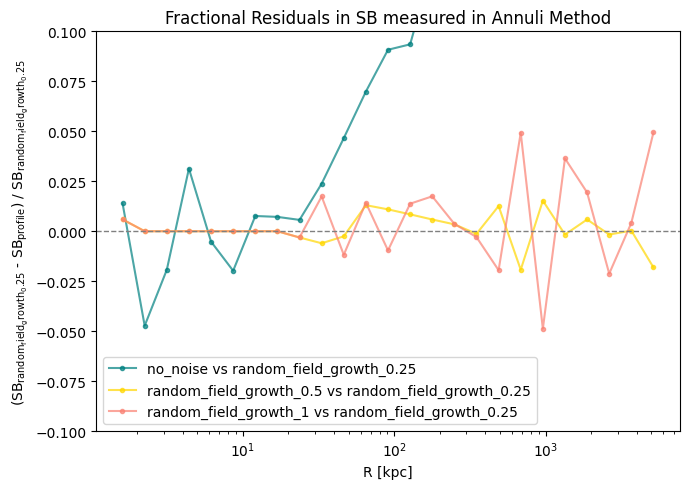

In [16]:
reference_label = "random_field_growth_0.25"

meas_dict = {label: meas for label, meas in measurements}

if reference_label not in meas_dict:
    raise ValueError(f"Reference label '{reference_label}' not found in measurements!")

ref_meas = meas_dict[reference_label]

ref_r_flux = dict(zip(ref_meas["R_kpc"], ref_meas["Clipped_median_flux_annulus"]))

fig, ax = plt.subplots(figsize=(7, 5))

for label, meas in measurements:
    if label == reference_label:
        continue

    other_r = meas["R_kpc"].values
    other_flux = meas["Clipped_median_flux_annulus"].values

    common_r = np.array([r for r in other_r if r in ref_r_flux])
    
    if len(common_r) == 0:
        print(f"No common radii found between '{reference_label}' and '{label}'")
        continue

    ref_flux_vals = np.array([ref_r_flux[r] for r in common_r])
    other_flux_vals = np.array([meas.loc[meas["R_kpc"] == r, "Clipped_median_flux_annulus"].values[0] for r in common_r])

    residual_fraction = (ref_flux_vals - other_flux_vals) / ref_flux_vals

    color = prefix_colors.get(label, "black")
    ax.plot(
        common_r, residual_fraction,
        label=f"{label} vs {reference_label}",
        color=color,
        linestyle="-",
        marker="o",
        ms=3,
        alpha=0.7
    )

ax.axhline(0, color="gray", linestyle="--", lw=1)
ax.set_xscale('log')
ax.set_xlabel("R [kpc]")
ax.set_ylabel(
    fr"(SB$\rm _{{{reference_label}}}$ - SB$\rm _{{profile}}$) / SB$\rm _{{{reference_label}}}$")
    
ax.set_title(f"Fractional Residuals in SB measured in Annuli Method")
ax.legend()

# ax.set_xlim(0,300)
ax.set_ylim(-0.1,.1)
plt.tight_layout()
plt.show()


# Fractional change in SB between a given profile from isophote method and the rest 

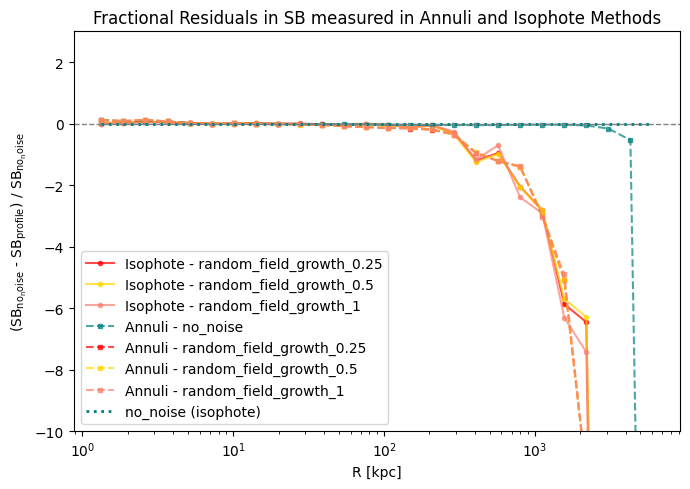

In [17]:
reference_label = "no_noise"

prof_dict = {label: prof for label, prof in profiles}
if reference_label not in prof_dict:
    raise ValueError(f"Reference label '{reference_label}' not found in profiles!")

ref_prof = prof_dict[reference_label]
ref_r = ref_prof["R_kpc"].values
ref_flux = ref_prof["I"].values

fig, ax = plt.subplots(figsize=(7, 5))

#  Comparing other isophote profile measurements 
for label, prof in profiles:
    if label == reference_label:
        continue

    other_r = prof["R_kpc"].values
    other_flux = prof["I"].values

    interp_flux = np.interp(ref_r, other_r, other_flux)
    residual_fraction = (ref_flux - interp_flux) / ref_flux

    color = prefix_colors.get(label, "black")
    ax.plot(
        ref_r, residual_fraction,
        label=f"Isophote - {label}",
        color=color,
        linestyle="-",
        marker="o",
        ms=3,
        alpha=0.7
    )

#  Comparing annuli profile measurements 
for label, meas in measurements:
    other_r = meas["R_kpc"].values
    other_flux = meas["Clipped_median_flux_annulus"].values

    interp_flux = np.interp(ref_r, other_r, other_flux)
    residual_fraction = (ref_flux - interp_flux) / ref_flux

    color = prefix_colors.get(label, "black")
    ax.plot(
        ref_r, residual_fraction,
        label=f"Annuli - {label}",
        color=color,
        linestyle="--",
        marker="s",
        ms=3,
        alpha=0.7
    )

ax.plot(
    ref_r, np.zeros_like(ref_r),
    label=f"{reference_label} (isophote)",
    color=prefix_colors.get(reference_label, "gray"),
    linestyle="dotted",
    linewidth=2
)


ax.axhline(0, color="gray", linestyle="--", lw=1)
ax.set_xscale('log')
ax.set_xlabel("R [kpc]")

ax.set_ylabel(
    fr"(SB$\rm _{{{reference_label}}}$ - SB$\rm _{{profile}}$) / SB$\rm _{{{reference_label}}}$"
)
ax.set_title(f"Fractional Residuals in SB measured in Annuli and Isophote Methods")
ax.set_ylim(-10,3)

ax.legend()
plt.tight_layout()
plt.show()
